In [2]:
import geopandas as gpd

from qgis.core import QgsApplication, QgsVectorLayer, QgsProcessingFeedback
from processing.core.Processing import Processing
import processing

In [3]:
Processing.initialize()

In [4]:
for alg in QgsApplication.processingRegistry().algorithms():
    if "native:" in alg.id():
        print(alg.id(), "--->", alg.displayName())

native:addautoincrementalfield ---> Add autoincremental field
native:addfieldtoattributestable ---> Add field to attributes table
native:adduniquevalueindexfield ---> Add unique value index field
native:addxyfields ---> Add X/Y fields to layer
native:affinetransform ---> Affine transform
native:aggregate ---> Aggregate
native:angletonearest ---> Align points to features
native:antimeridiansplit ---> Geodesic line split at antimeridian
native:arrayoffsetlines ---> Array of offset (parallel) lines
native:arraytranslatedfeatures ---> Array of translated features
native:aspect ---> Aspect
native:assignprojection ---> Assign projection
native:atlaslayouttoimage ---> Export atlas layout as image
native:atlaslayouttomultiplepdf ---> Export atlas layout as PDF (multiple files)
native:atlaslayouttopdf ---> Export atlas layout as PDF (single file)
native:batchnominatimgeocoder ---> Batch Nominatim geocoder
native:bookmarkstolayer ---> Convert spatial bookmarks to layer
native:boundary ---> Bound

In [5]:
processing.algorithmHelp("native:extractvertices")

Extract vertices (native:extractvertices)

This algorithm takes a line or polygon layer and generates a point layer with points representing the vertices in the input lines or polygons. The attributes associated to each point are the same ones associated to the line or polygon that the point belongs to.

Additional fields are added to the point indicating the vertex index (beginning at 0), the vertex’s part and its index within the part (as well as its ring for polygons), distance along original geometry and bisector angle of vertex for original geometry.


----------------
Input parameters
----------------

INPUT: Input layer

	Parameter type:	QgsProcessingParameterFeatureSource

	Accepted data types:
		- str: layer ID
		- str: layer name
		- str: layer source
		- QgsProcessingFeatureSourceDefinition
		- QgsProperty
		- QgsVectorLayer

OUTPUT: Vertices

	Parameter type:	QgsProcessingParameterFeatureSink

	Accepted data types:
		- str: destination vector file, e.g. 'd:/test.shp'
		- st

In [6]:
input_vector = QgsVectorLayer("./data/test.geojson")
output_filename = "./data/vertices.geojson"
params = {
    'INPUT': input_vector,
    'OUTPUT': output_filename
}
feedback = QgsProcessingFeedback()

processing.run("native:extractvertices", params, feedback=feedback)

{'OUTPUT': './data/vertices.geojson'}

<AxesSubplot: >

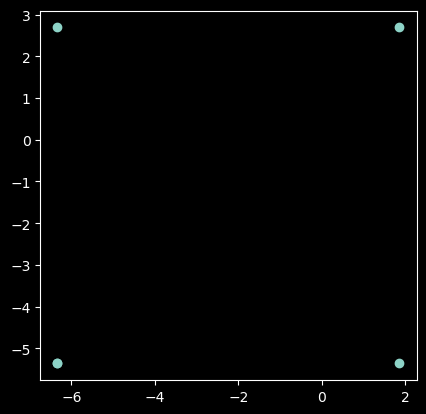

In [7]:
gdf = gpd.read_file(output_filename)
gdf.plot()

In [8]:
gdf.explore()